In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
sales = pd.read_csv("../../../Data/sales.csv")
products = pd.read_csv("../../../Data/products.csv")
stores = pd.read_csv("../../../Data/stores.csv")
category = pd.read_csv("../../../Data/category.csv")
warranty = pd.read_csv("../../../Data/warranty.csv")

In [3]:
Parse sale_date and plot the monthly units-sold trend across the full sales.csv dataset.

SyntaxError: invalid syntax (1543584509.py, line 1)

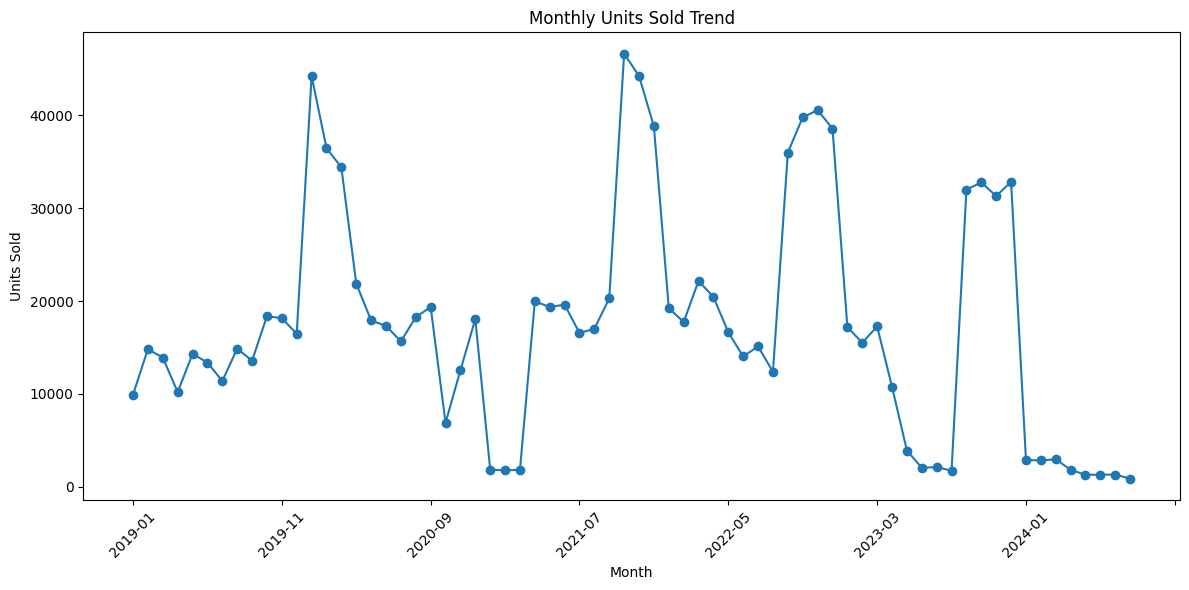

In [4]:
sales["sale_date"] = pd.to_datetime(sales["sale_date"])

monthly_units = (
    sales
    .groupby(sales["sale_date"].dt.to_period("M"))["quantity"]
    .sum()
)

monthly_units.index = monthly_units.index.astype(str)


plt.figure(figsize=(12, 6))

monthly_units.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [5]:
Join sales.csv and products.csv to derive revenue, then plot the monthly revenue trend with markers at each point

SyntaxError: invalid syntax (1956911565.py, line 1)

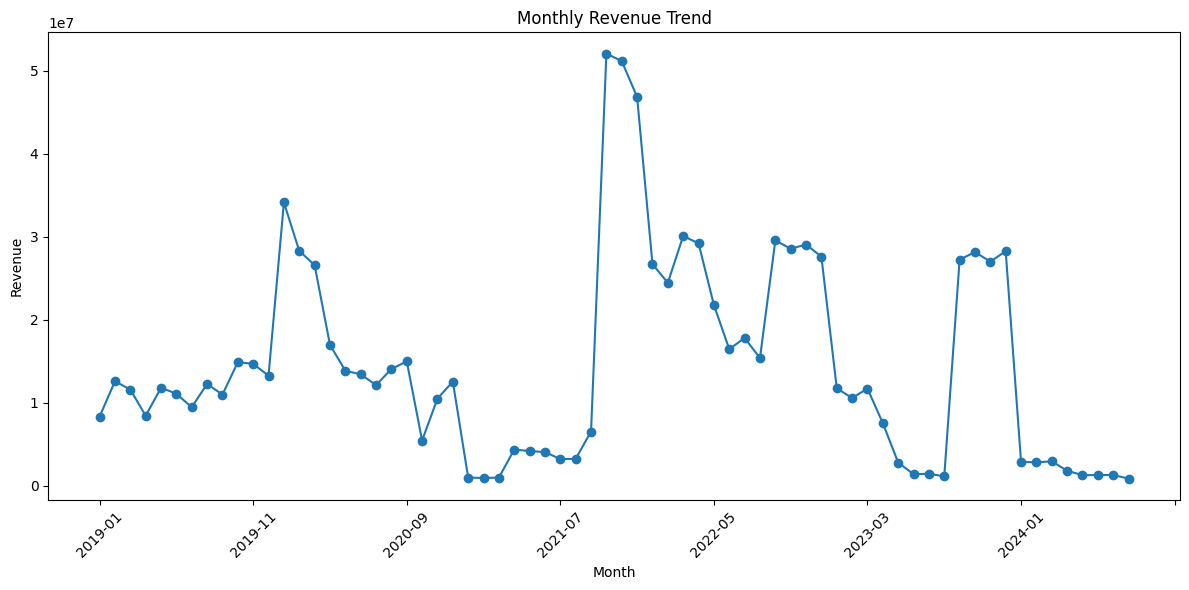

In [6]:
sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] * sales_products["price"]
)


sales_products["sale_date"] = pd.to_datetime(
    sales_products["sale_date"]
)


monthly_revenue = (
    sales_products
    .groupby(sales_products["sale_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)


plt.figure(figsize=(12, 6))

monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
Filter sales.csv to one Nov–Dec holiday window and plot the daily quantity trend, marking the single highest-volume day

SyntaxError: invalid character '–' (U+2013) (63858278.py, line 1)

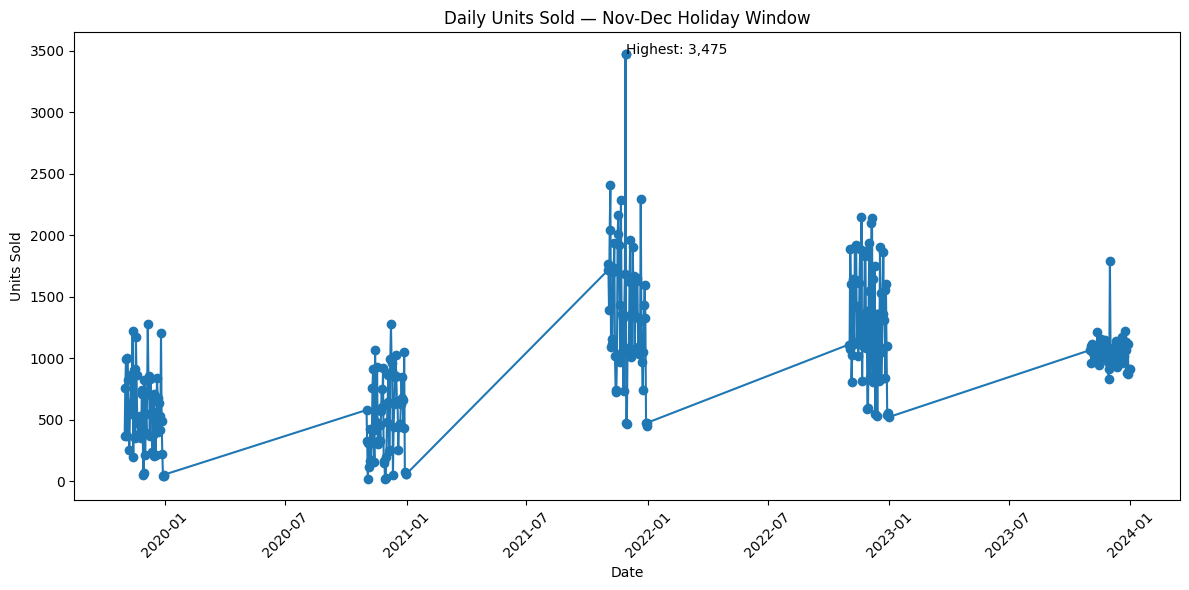

In [9]:
sales["sale_date"] = pd.to_datetime(sales["sale_date"])


holiday_sales = sales[
    (sales["sale_date"].dt.month >= 11) &
    (sales["sale_date"].dt.month <= 12)
]


daily_quantity = (
    holiday_sales
    .groupby(holiday_sales["sale_date"].dt.date)["quantity"]
    .sum()
)


highest_day = daily_quantity.idxmax()
highest_quantity = daily_quantity.max()

plt.figure(figsize=(12, 6))

daily_quantity.plot(
    kind="line",
    marker="o"
)


plt.scatter(
    highest_day,
    highest_quantity
)

plt.annotate(
    f"Highest: {highest_quantity:,.0f}",
    (highest_day, highest_quantity)
)

plt.title("Daily Units Sold — Nov-Dec Holiday Window")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
Compare monthly revenue trends across 2019–2023 using both plt.plot() and sns.lineplot(), and explain why 2024 should be excluded
from the comparison.

SyntaxError: invalid character '–' (U+2013) (3499832200.py, line 1)

In [12]:
# Revenue + Dates

sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] * sales_products["price"]
)

sales_products["sale_date"] = pd.to_datetime(
    sales_products["sale_date"]
)

In [14]:
# 2019 - 2023

sales_2019_2023 = sales_products[
    (sales_products["sale_date"].dt.year >= 2019) &
    (sales_products["sale_date"].dt.year <= 2023)
]

In [17]:
# Monthly Revenue
sales_2019_2023["year"] = sales_2019_2023["sale_date"].dt.year
sales_2019_2023["month"] = sales_2019_2023["sale_date"].dt.month

monthly_revenue = (
    sales_2019_2023
    .groupby(["year", "month"])["revenue"]
    .sum()
    .reset_index()
)

C:\Users\mohak\AppData\Local\Temp\ipykernel_13448\2267746320.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_2019_2023["year"] = sales_2019_2023["sale_date"].dt.year
C:\Users\mohak\AppData\Local\Temp\ipykernel_13448\2267746320.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_2019_2023["month"] = sales_2019_2023["sale_date"].dt.month


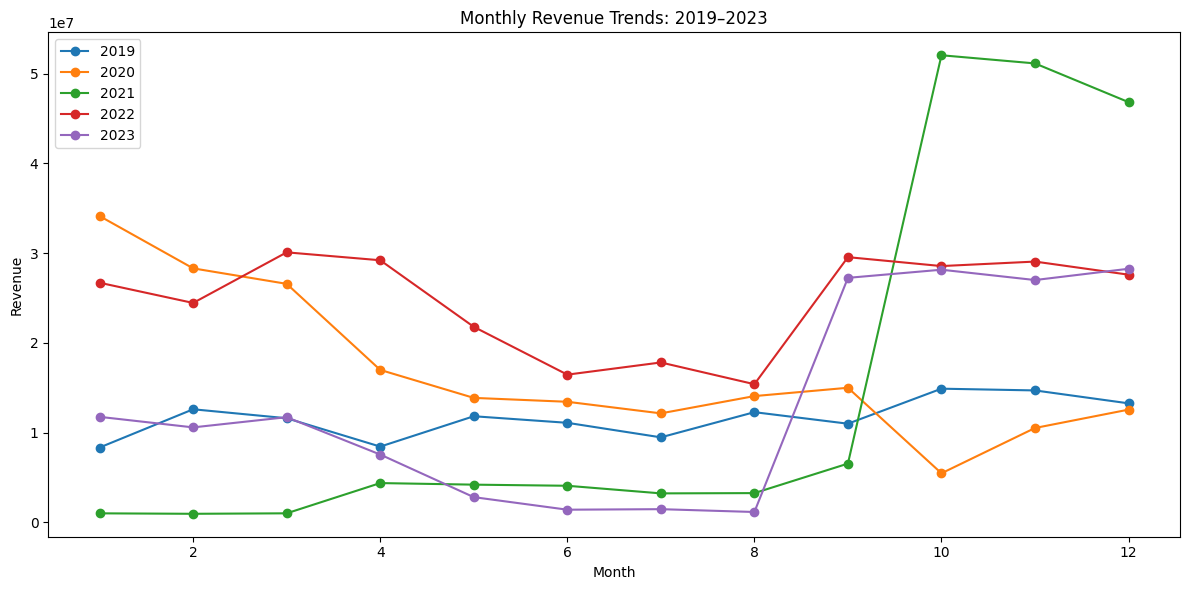

In [18]:
plt.figure(figsize=(12, 6))

for year in monthly_revenue["year"].unique():

    data = monthly_revenue[
        monthly_revenue["year"] == year
    ]

    plt.plot(
        data["month"],
        data["revenue"],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Revenue Trends: 2019–2023")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
Combine the monthly units and revenue trends into one two-panel figure, label the single highest-revenue month, and explain what
the seasonal pattern suggests for inventory planning.

SyntaxError: invalid syntax (3897004936.py, line 1)

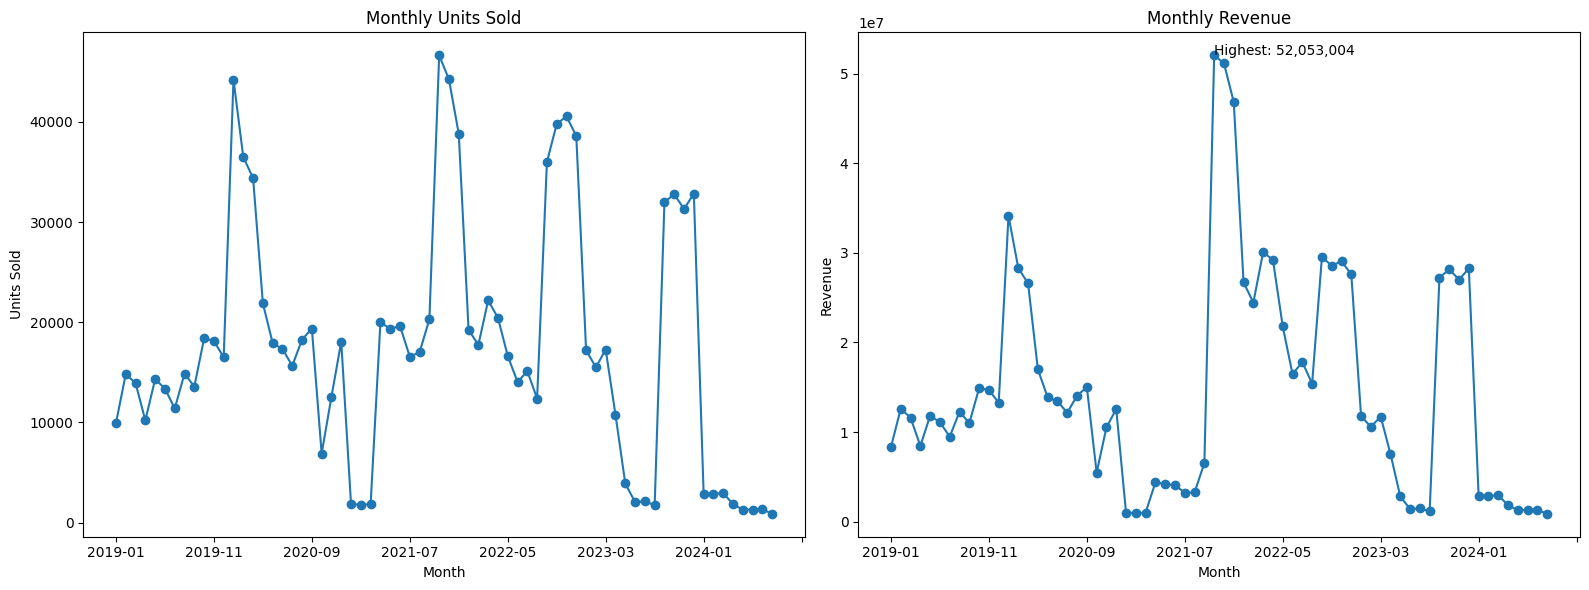

In [20]:
# =========================
# 1. MONTHLY UNITS
# =========================

monthly_units = (
    sales
    .groupby(sales["sale_date"].dt.to_period("M"))["quantity"]
    .sum()
)

monthly_units.index = monthly_units.index.astype(str)


# =========================
# 2. REVENUE
# =========================

sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] * sales_products["price"]
)


# =========================
# 3. MONTHLY REVENUE
# =========================

monthly_revenue = (
    sales_products
    .groupby(sales_products["sale_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)


# =========================
# 4. HIGHEST REVENUE MONTH
# =========================

highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()


# =========================
# 5. TWO-PANEL CHART
# =========================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)


# Monthly Units
monthly_units.plot(
    kind="line",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Monthly Units Sold")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Units Sold")


# Monthly Revenue
revenue_chart = monthly_revenue.plot(
    kind="line",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Monthly Revenue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue")


# Highest revenue month ko mark karna
highest_position = list(monthly_revenue.index).index(highest_month)

axes[1].annotate(
    f"Highest: {highest_revenue:,.0f}",
    (highest_position, highest_revenue)
)


plt.tight_layout()
plt.show()